# Music Genre Classification - Model Evaluation

This notebook provides comprehensive evaluation of music genre classification models.

## Objectives
1. Load and prepare data
2. Train multiple models
3. Comprehensive evaluation with all metrics
4. Visualizations and analysis
5. Model interpretation


In [1]:
# Import required libraries
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score,
    log_loss, roc_curve, precision_recall_curve, auc
)
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
import warnings
warnings.filterwarnings('ignore')

# Add parent directory to path
sys.path.insert(0, str(Path().absolute().parent))

from src.preprocessing import DataAcquisition, DataProcessor
from src.model import GenreClassifier, compare_models

# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Load and Prepare Data


In [2]:
# Load data
print("Loading data...")
data_acq = DataAcquisition(base_path="../data/dataset")
df = data_acq.load_csv_features()

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()[:10]}...")  # Show first 10 columns
print(f"\nGenre distribution:")
print(df['label'].value_counts().sort_index())


2025-11-26 22:00:03,812 - src.preprocessing - INFO - Initialized DataAcquisition with base_path: ../data/dataset
2025-11-26 22:00:03,813 - src.preprocessing - INFO - Loading CSV features from: ../data/dataset/features_30_sec.csv
2025-11-26 22:00:03,843 - src.preprocessing - INFO - Successfully loaded 1000 rows from CSV
2025-11-26 22:00:03,843 - src.preprocessing - INFO - Columns: ['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean', 'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var', 'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean', 'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var', 'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo', 'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean', 'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var', 'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean', 'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var',

Loading data...
Dataset shape: (1000, 60)
Columns: ['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean', 'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var', 'spectral_bandwidth_mean', 'spectral_bandwidth_var']...

Genre distribution:
label
blues        100
classical    100
country      100
disco        100
hiphop       100
jazz         100
metal        100
pop          100
reggae       100
rock         100
Name: count, dtype: int64


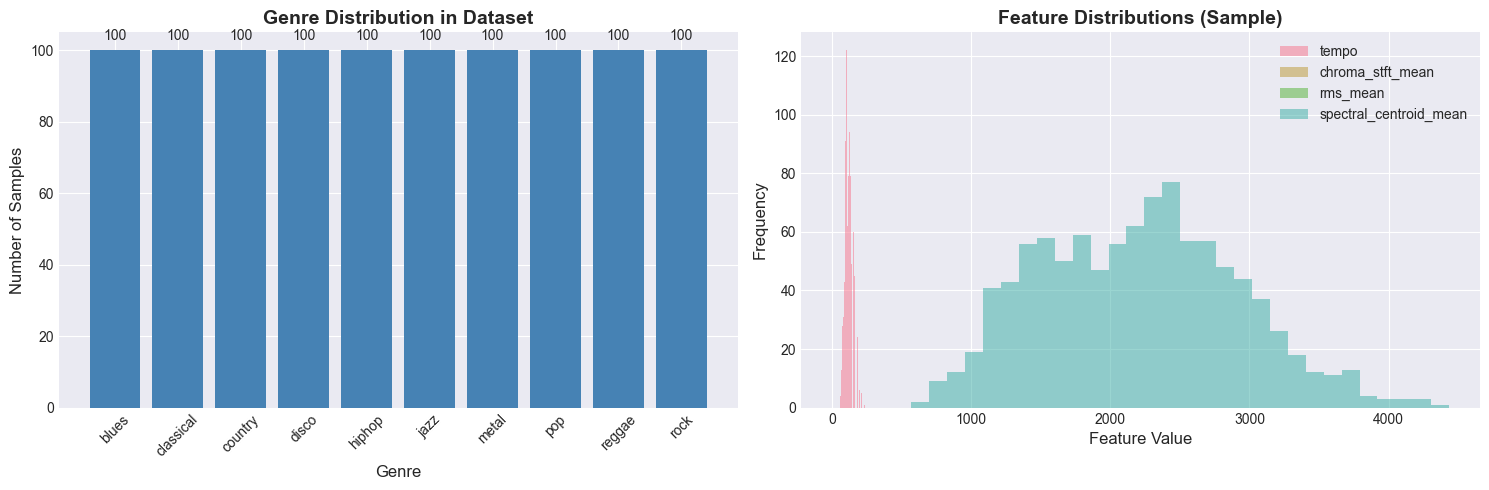

Total samples: 1000
Number of genres: 10
Number of features: 58


In [3]:
# Visualize data distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Genre distribution
genre_counts = df['label'].value_counts().sort_index()
axes[0].bar(genre_counts.index, genre_counts.values, color='steelblue')
axes[0].set_title('Genre Distribution in Dataset', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Genre', fontsize=12)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(genre_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', va='bottom')

# Feature distribution (sample a few features)
sample_features = ['tempo', 'chroma_stft_mean', 'rms_mean', 'spectral_centroid_mean']
for feature in sample_features:
    if feature in df.columns:
        axes[1].hist(df[feature], alpha=0.5, label=feature, bins=30)
axes[1].set_title('Feature Distributions (Sample)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Feature Value', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Total samples: {len(df)}")
print(f"Number of genres: {df['label'].nunique()}")
print(f"Number of features: {len(df.columns) - 2}")  # Exclude filename and label


In [4]:
# Split data into train/test
train_df, test_df = data_acq.split_data(df, test_size=0.2, random_state=42)

print(f"Train set: {len(train_df)} samples ({len(train_df)/len(df)*100:.1f}%)")
print(f"Test set: {len(test_df)} samples ({len(test_df)/len(df)*100:.1f}%)")


2025-11-26 22:00:25,252 - src.preprocessing - INFO - Splitting data with test_size=0.2, random_state=42, stratify=True
2025-11-26 22:00:25,257 - src.preprocessing - INFO - Train set: 800 samples (80.0%)
2025-11-26 22:00:25,258 - src.preprocessing - INFO - Test set: 200 samples (20.0%)
2025-11-26 22:00:25,259 - src.preprocessing - INFO - Train set label distribution:
2025-11-26 22:00:25,259 - src.preprocessing - INFO -   blues: 80 samples
2025-11-26 22:00:25,259 - src.preprocessing - INFO -   classical: 80 samples
2025-11-26 22:00:25,259 - src.preprocessing - INFO -   country: 80 samples
2025-11-26 22:00:25,259 - src.preprocessing - INFO -   disco: 80 samples
2025-11-26 22:00:25,259 - src.preprocessing - INFO -   hiphop: 80 samples
2025-11-26 22:00:25,260 - src.preprocessing - INFO -   jazz: 80 samples
2025-11-26 22:00:25,260 - src.preprocessing - INFO -   metal: 80 samples
2025-11-26 22:00:25,260 - src.preprocessing - INFO -   pop: 80 samples
2025-11-26 22:00:25,260 - src.preprocessing

Train set: 800 samples (80.0%)
Test set: 200 samples (20.0%)


In [5]:
# Process data
processor = DataProcessor(models_dir="../models")
X_train, y_train, metadata = processor.process_training_data(train_df)
X_test, y_test = processor.process_test_data(test_df)

class_names = metadata['class_names']
feature_names = metadata['feature_names']

print(f"Training data shape: X={X_train.shape}, y={y_train.shape}")
print(f"Test data shape: X={X_test.shape}, y={y_test.shape}")
print(f"\nClass names: {class_names}")
print(f"Number of features: {len(feature_names)}")


2025-11-26 22:00:31,531 - src.preprocessing - INFO - Initialized DataProcessor with models_dir: ../models
2025-11-26 22:00:31,531 - src.preprocessing - INFO - ============================================================
2025-11-26 22:00:31,532 - src.preprocessing - INFO - Processing Training Data
2025-11-26 22:00:31,532 - src.preprocessing - INFO - ============================================================
2025-11-26 22:00:31,533 - src.preprocessing - INFO - Starting data cleaning...
2025-11-26 22:00:31,545 - src.preprocessing - INFO - Removed 268 outliers using IQR method
2025-11-26 22:00:31,545 - src.preprocessing - INFO - Data cleaning completed: 800 -> 532 samples
2025-11-26 22:00:31,546 - src.preprocessing - INFO - Prepared 57 features and 532 labels
2025-11-26 22:00:31,547 - src.preprocessing - INFO - Fitted label encoder with 10 classes
2025-11-26 22:00:31,547 - src.preprocessing - INFO - Label mapping: {'blues': np.int64(0), 'classical': np.int64(1), 'country': np.int64(2), '

Training data shape: X=(532, 57), y=(532,)
Test data shape: X=(200, 57), y=(200,)

Class names: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Number of features: 57


## 2. Train Multiple Models


In [6]:
# Train multiple models and compare
model_types = ['random_forest', 'svm', 'mlp']
# Add xgboost if available
try:
    import xgboost
    model_types.append('xgboost')
except ImportError:
    print("XGBoost not available, skipping...")

print(f"Training models: {model_types}")

comparison_results = compare_models(
    X_train, y_train,
    X_test, y_test,
    model_types=model_types,
    class_names=class_names
)


2025-11-26 22:00:37,023 - src.model - INFO - 
2025-11-26 22:00:37,023 - src.model - INFO - Training and evaluating random_forest
2025-11-26 22:00:37,023 - src.model - INFO - ============================================================
2025-11-26 22:00:37,024 - src.model - INFO - Initialized random_forest classifier
2025-11-26 22:00:37,024 - src.model - INFO - Training random_forest model...
2025-11-26 22:00:37,025 - src.model - INFO - Training data shape: X=(532, 57), y=(532,)
2025-11-26 22:00:37,152 - src.model - INFO - Performing 5-fold cross-validation...


Training models: ['random_forest', 'svm', 'mlp', 'xgboost']


2025-11-26 22:00:37,558 - src.model - INFO - CV Accuracy: 0.6729 (+/- 0.0482)
2025-11-26 22:00:37,573 - src.model - INFO - Model training completed. Train accuracy: 0.9981
2025-11-26 22:00:37,574 - src.model - INFO - Evaluating model on test set...
2025-11-26 22:00:37,610 - src.model - INFO - Test Accuracy: 0.6650
2025-11-26 22:00:37,610 - src.model - INFO - Test Precision: 0.6640
2025-11-26 22:00:37,610 - src.model - INFO - Test Recall: 0.6650
2025-11-26 22:00:37,610 - src.model - INFO - Test F1-Score: 0.6586
2025-11-26 22:00:37,611 - src.model - INFO - random_forest completed successfully
2025-11-26 22:00:37,611 - src.model - INFO - 
2025-11-26 22:00:37,611 - src.model - INFO - Training and evaluating svm
2025-11-26 22:00:37,611 - src.model - INFO - ============================================================
2025-11-26 22:00:37,612 - src.model - INFO - Initialized svm classifier
2025-11-26 22:00:37,612 - src.model - INFO - Training svm model...
2025-11-26 22:00:37,612 - src.model - 

   model_type  train_accuracy  cv_mean   cv_std  test_accuracy  test_precision  test_recall  test_f1
random_forest        0.998120 0.672932 0.024114          0.665        0.664011        0.665 0.658602
          svm        0.917293 0.706718 0.033285          0.635        0.706377        0.635 0.647010
          mlp        0.998120 0.697320 0.039158          0.615        0.641983        0.615 0.613393
      xgboost        0.998120 0.714318 0.035781          0.655        0.671927        0.655 0.654672


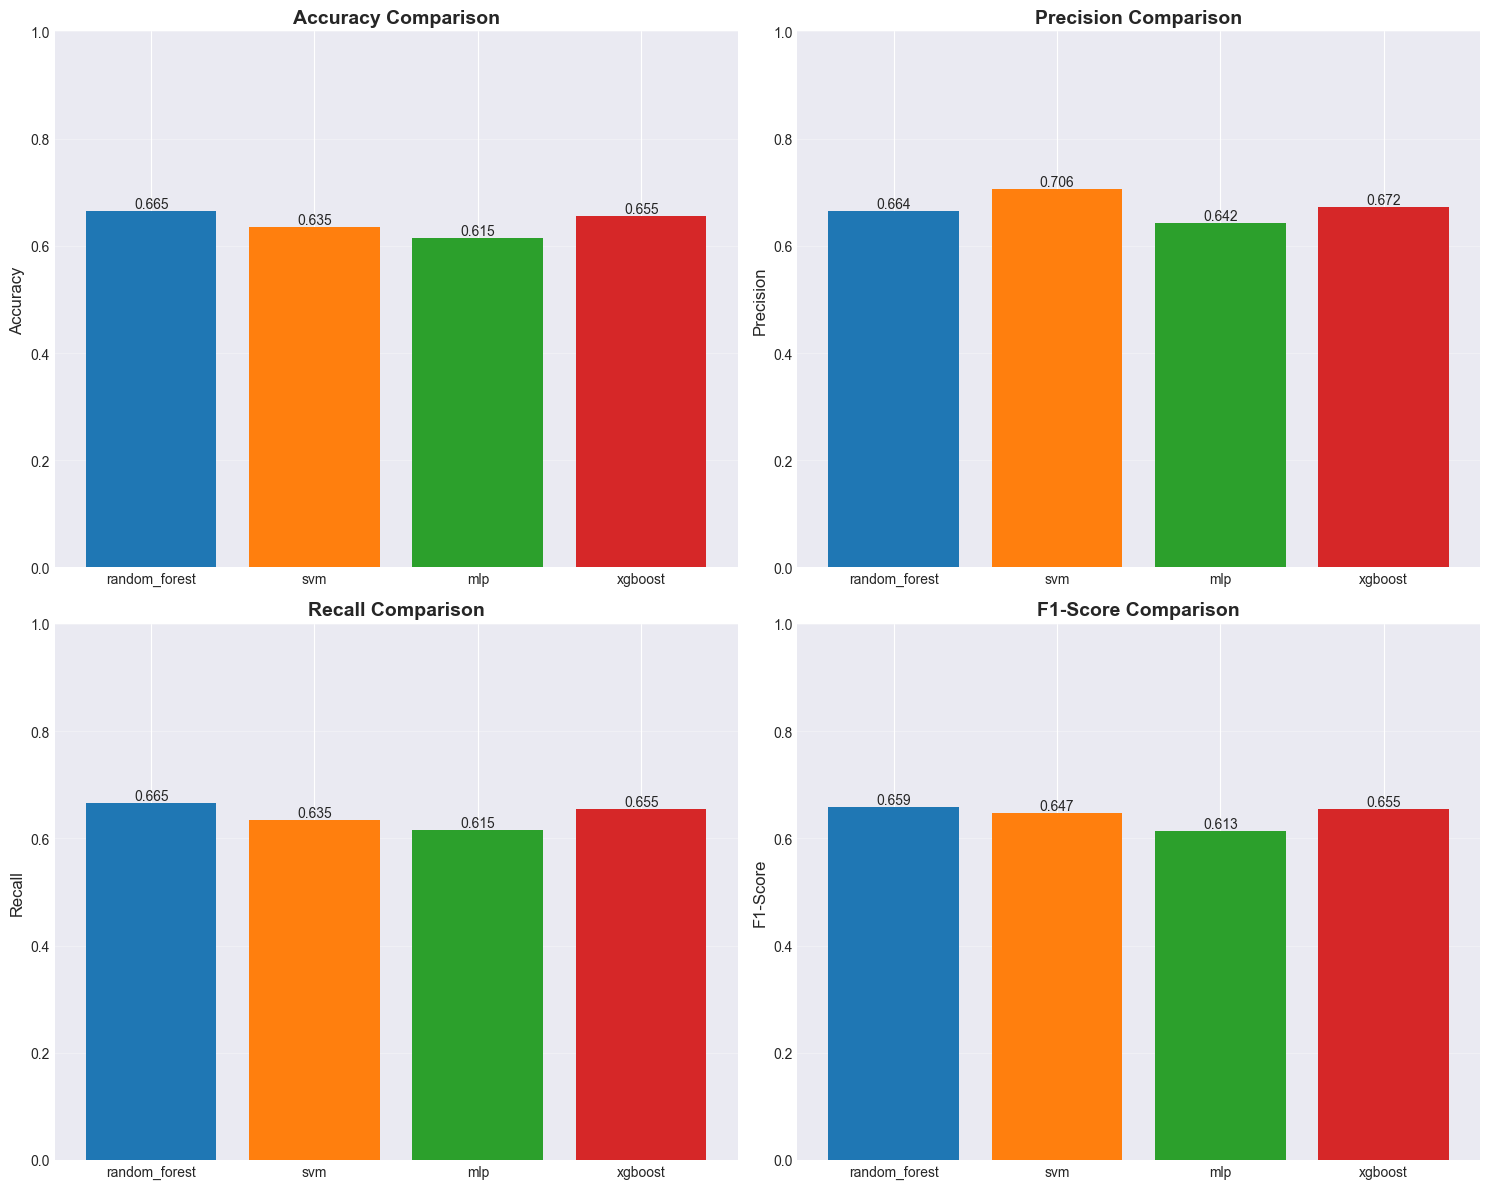

In [7]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

metrics_to_plot = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for idx, (metric, label) in enumerate(zip(metrics_to_plot, metric_labels)):
    ax = axes[idx // 2, idx % 2]
    if metric in comparison_results.columns:
        bars = ax.bar(comparison_results['model_type'], comparison_results[metric], 
                     color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'][:len(comparison_results)])
        ax.set_title(f'{label} Comparison', fontsize=14, fontweight='bold')
        ax.set_ylabel(label, fontsize=12)
        ax.set_ylim([0, 1])
        ax.grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


## 3. Comprehensive Evaluation (Best Model)

We'll use the best performing model for detailed evaluation.


In [8]:
# Select best model based on test accuracy
best_model_type = comparison_results.loc[comparison_results['test_accuracy'].idxmax(), 'model_type']
print(f"Best model: {best_model_type}")
print(f"Test Accuracy: {comparison_results.loc[comparison_results['test_accuracy'].idxmax(), 'test_accuracy']:.4f}")

# Load or train best model
classifier = GenreClassifier(model_type=best_model_type, models_dir="../models")
classifier.train(X_train, y_train, use_cross_validation=True)

# Evaluate on test set
test_metrics = classifier.evaluate(X_test, y_test, class_names=class_names)


2025-11-26 22:01:34,783 - src.model - INFO - Initialized random_forest classifier
2025-11-26 22:01:34,783 - src.model - INFO - Training random_forest model...
2025-11-26 22:01:34,783 - src.model - INFO - Training data shape: X=(532, 57), y=(532,)
2025-11-26 22:01:34,882 - src.model - INFO - Performing 5-fold cross-validation...


Best model: random_forest
Test Accuracy: 0.6650


2025-11-26 22:01:35,347 - src.model - INFO - CV Accuracy: 0.6729 (+/- 0.0482)
2025-11-26 22:01:35,361 - src.model - INFO - Model training completed. Train accuracy: 0.9981
2025-11-26 22:01:35,362 - src.model - INFO - Evaluating model on test set...
2025-11-26 22:01:35,400 - src.model - INFO - Test Accuracy: 0.6650
2025-11-26 22:01:35,400 - src.model - INFO - Test Precision: 0.6640
2025-11-26 22:01:35,400 - src.model - INFO - Test Recall: 0.6650
2025-11-26 22:01:35,401 - src.model - INFO - Test F1-Score: 0.6586


### 3.1 Classification Metrics


In [9]:
# Get predictions
y_pred = classifier.predict(X_test)
y_proba = classifier.predict_proba(X_test)

# Calculate all metrics
print("="*60)
print("COMPREHENSIVE EVALUATION METRICS")
print("="*60)

# Overall metrics
print("\n1. OVERALL METRICS:")
print(f"   Accuracy: {test_metrics['accuracy']:.4f} ({test_metrics['accuracy']*100:.2f}%)")
print(f"   Precision (Weighted): {test_metrics['precision_weighted']:.4f}")
print(f"   Recall (Weighted): {test_metrics['recall_weighted']:.4f}")
print(f"   F1-Score (Weighted): {test_metrics['f1_weighted']:.4f}")

# Macro averages
precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)

print(f"\n2. MACRO AVERAGES:")
print(f"   Precision (Macro): {precision_macro:.4f}")
print(f"   Recall (Macro): {recall_macro:.4f}")
print(f"   F1-Score (Macro): {f1_macro:.4f}")

# Micro averages
precision_micro = precision_score(y_test, y_pred, average='micro', zero_division=0)
recall_micro = recall_score(y_test, y_pred, average='micro', zero_division=0)
f1_micro = f1_score(y_test, y_pred, average='micro', zero_division=0)

print(f"\n3. MICRO AVERAGES:")
print(f"   Precision (Micro): {precision_micro:.4f}")
print(f"   Recall (Micro): {recall_micro:.4f}")
print(f"   F1-Score (Micro): {f1_micro:.4f}")

# Per-class metrics
print(f"\n4. PER-CLASS METRICS:")
per_class_df = pd.DataFrame({
    'Genre': class_names,
    'Precision': test_metrics['precision_per_class'],
    'Recall': test_metrics['recall_per_class'],
    'F1-Score': test_metrics['f1_per_class']
})
print(per_class_df.to_string(index=False))


COMPREHENSIVE EVALUATION METRICS

1. OVERALL METRICS:
   Accuracy: 0.6650 (66.50%)
   Precision (Weighted): 0.6640
   Recall (Weighted): 0.6650
   F1-Score (Weighted): 0.6586

2. MACRO AVERAGES:
   Precision (Macro): 0.6640
   Recall (Macro): 0.6650
   F1-Score (Macro): 0.6586

3. MICRO AVERAGES:
   Precision (Micro): 0.6650
   Recall (Micro): 0.6650
   F1-Score (Micro): 0.6650

4. PER-CLASS METRICS:
    Genre  Precision  Recall  F1-Score
    blues   0.714286    0.75  0.731707
classical   0.818182    0.90  0.857143
  country   0.760000    0.95  0.844444
    disco   0.352941    0.30  0.324324
   hiphop   0.434783    0.50  0.465116
     jazz   0.700000    0.70  0.700000
    metal   0.882353    0.75  0.810811
      pop   0.708333    0.85  0.772727
   reggae   0.500000    0.45  0.473684
     rock   0.769231    0.50  0.606061


In [10]:
# Additional metrics: Log Loss
log_loss_score = log_loss(y_test, y_proba)
print(f"\n5. ADDITIONAL METRICS:")
print(f"   Log Loss: {log_loss_score:.4f}")

# Top-K Accuracy (Top-2 and Top-3)
def top_k_accuracy(y_true, y_proba, k):
    """Calculate top-k accuracy."""
    top_k_pred = np.argsort(y_proba, axis=1)[:, -k:]
    return np.mean([y_true[i] in top_k_pred[i] for i in range(len(y_true))])

top2_accuracy = top_k_accuracy(y_test, y_proba, 2)
top3_accuracy = top_k_accuracy(y_test, y_proba, 3)

print(f"   Top-2 Accuracy: {top2_accuracy:.4f} ({top2_accuracy*100:.2f}%)")
print(f"   Top-3 Accuracy: {top3_accuracy:.4f} ({top3_accuracy*100:.2f}%)")



5. ADDITIONAL METRICS:
   Log Loss: 1.1028
   Top-2 Accuracy: 0.8400 (84.00%)
   Top-3 Accuracy: 0.9100 (91.00%)


In [11]:
# ROC-AUC Score (One-vs-Rest)
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]

# Calculate ROC-AUC for each class
roc_auc_scores = {}
for i, class_name in enumerate(class_names):
    roc_auc = roc_auc_score(y_test_binarized[:, i], y_proba[:, i])
    roc_auc_scores[class_name] = roc_auc

# Macro and micro averages
roc_auc_macro = np.mean(list(roc_auc_scores.values()))
roc_auc_micro = roc_auc_score(y_test_binarized.ravel(), y_proba.ravel())

print(f"\n6. ROC-AUC SCORES:")
print(f"   ROC-AUC (Macro): {roc_auc_macro:.4f}")
print(f"   ROC-AUC (Micro): {roc_auc_micro:.4f}")
print(f"\n   Per-Class ROC-AUC:")
for genre, score in sorted(roc_auc_scores.items(), key=lambda x: x[1], reverse=True):
    print(f"     {genre:12s}: {score:.4f}")



6. ROC-AUC SCORES:
   ROC-AUC (Macro): 0.9392
   ROC-AUC (Micro): 0.9445

   Per-Class ROC-AUC:
     classical   : 0.9943
     country     : 0.9858
     jazz        : 0.9810
     blues       : 0.9793
     pop         : 0.9733
     metal       : 0.9608
     hiphop      : 0.9526
     disco       : 0.8650
     reggae      : 0.8556
     rock        : 0.8446


### 3.2 Classification Report


In [12]:
# Print detailed classification report
print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))



DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

       blues       0.71      0.75      0.73        20
   classical       0.82      0.90      0.86        20
     country       0.76      0.95      0.84        20
       disco       0.35      0.30      0.32        20
      hiphop       0.43      0.50      0.47        20
        jazz       0.70      0.70      0.70        20
       metal       0.88      0.75      0.81        20
         pop       0.71      0.85      0.77        20
      reggae       0.50      0.45      0.47        20
        rock       0.77      0.50      0.61        20

    accuracy                           0.67       200
   macro avg       0.66      0.66      0.66       200
weighted avg       0.66      0.67      0.66       200



## 4. Visualizations


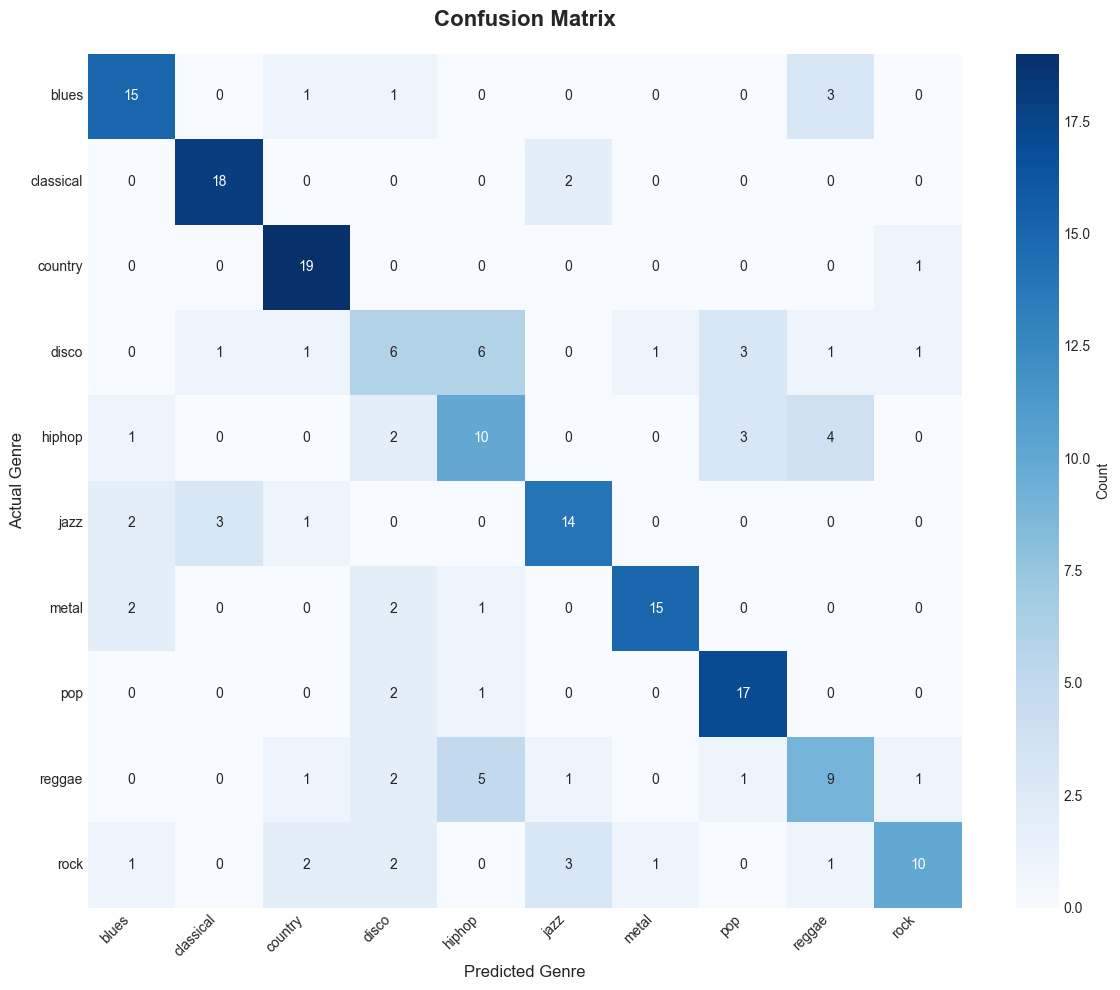

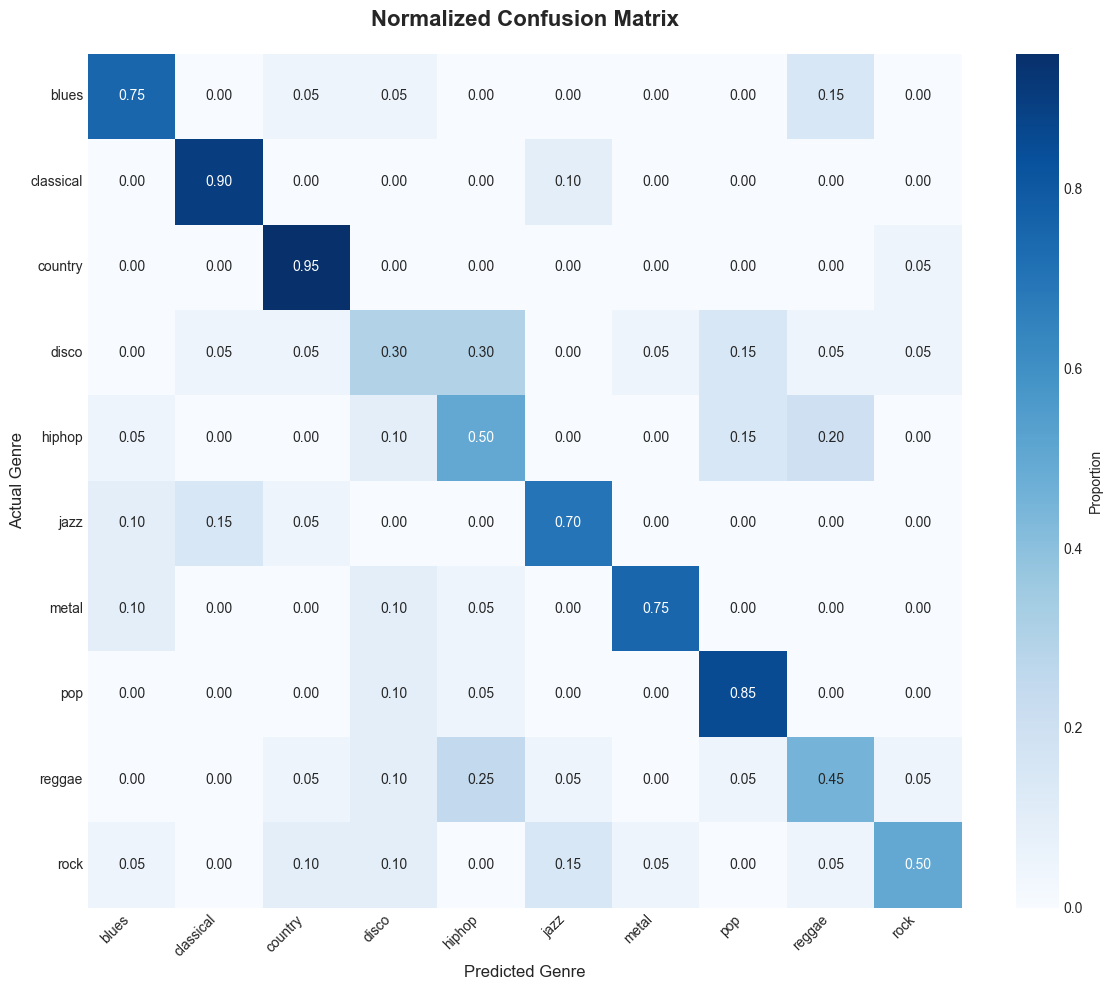

In [13]:
# 4.1 Confusion Matrix Heatmap
cm = np.array(test_metrics['confusion_matrix'])

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Genre', fontsize=12)
plt.ylabel('Actual Genre', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Calculate normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Proportion'})
plt.title('Normalized Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Genre', fontsize=12)
plt.ylabel('Actual Genre', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


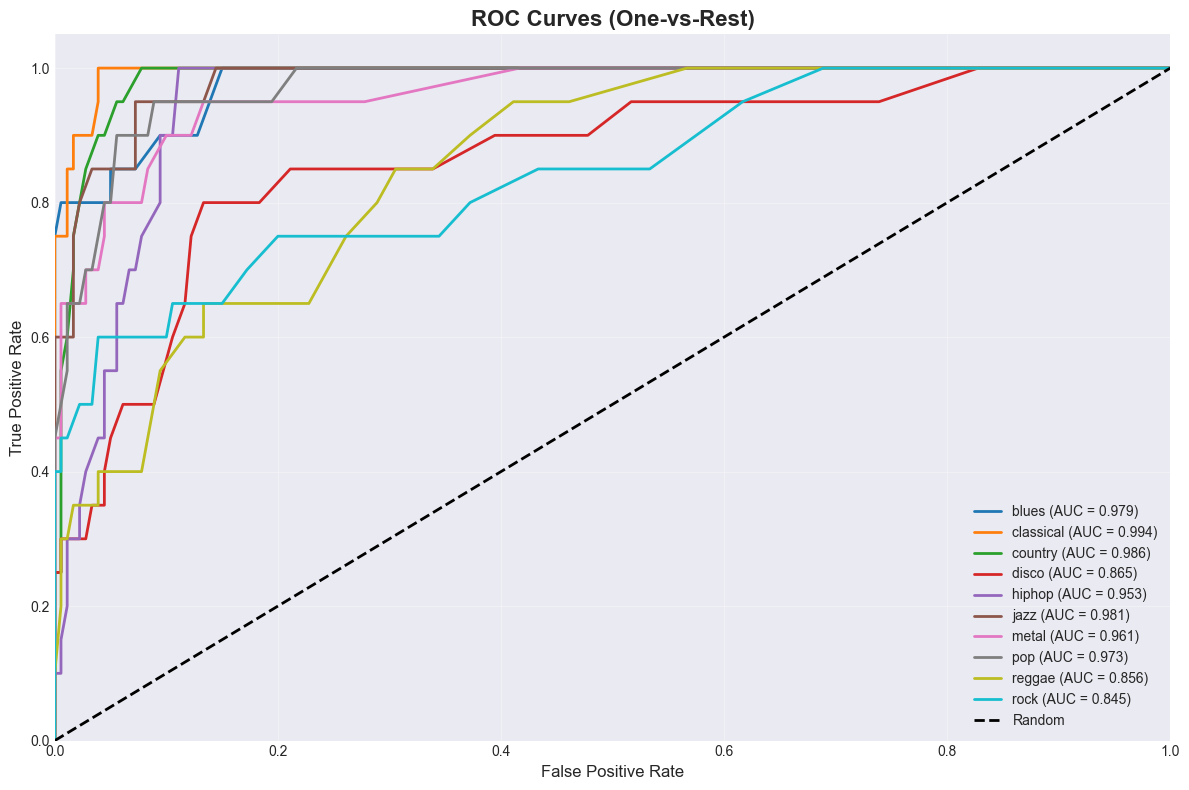

In [14]:
# 4.2 ROC Curves (One-vs-Rest)
plt.figure(figsize=(12, 8))

colors = plt.cm.get_cmap('tab10', n_classes)
for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_proba[:, i])
    roc_auc = roc_auc_scores[class_name]
    plt.plot(fpr, tpr, color=colors(i), lw=2,
             label=f'{class_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves (One-vs-Rest)', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


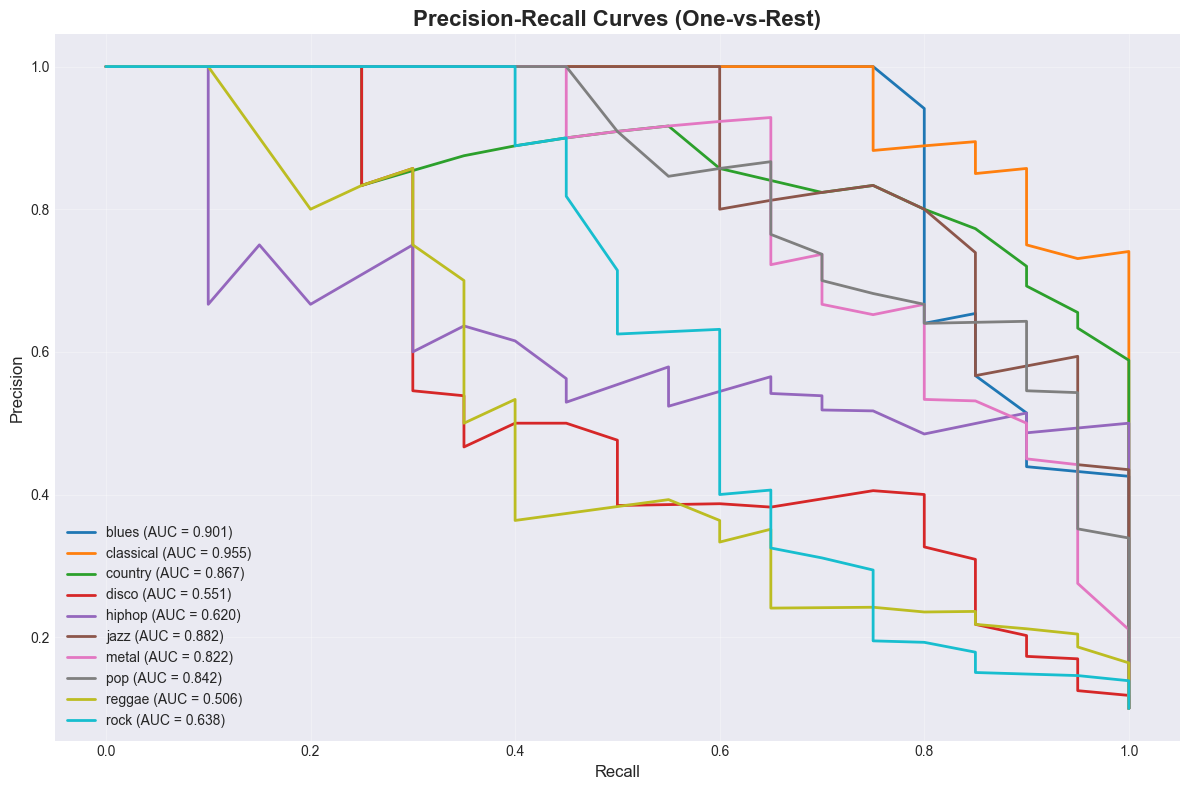

In [15]:
# 4.3 Precision-Recall Curves
plt.figure(figsize=(12, 8))

for i, class_name in enumerate(class_names):
    precision, recall, _ = precision_recall_curve(y_test_binarized[:, i], y_proba[:, i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, color=colors(i), lw=2,
             label=f'{class_name} (AUC = {pr_auc:.3f})')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves (One-vs-Rest)', fontsize=16, fontweight='bold')
plt.legend(loc="lower left", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


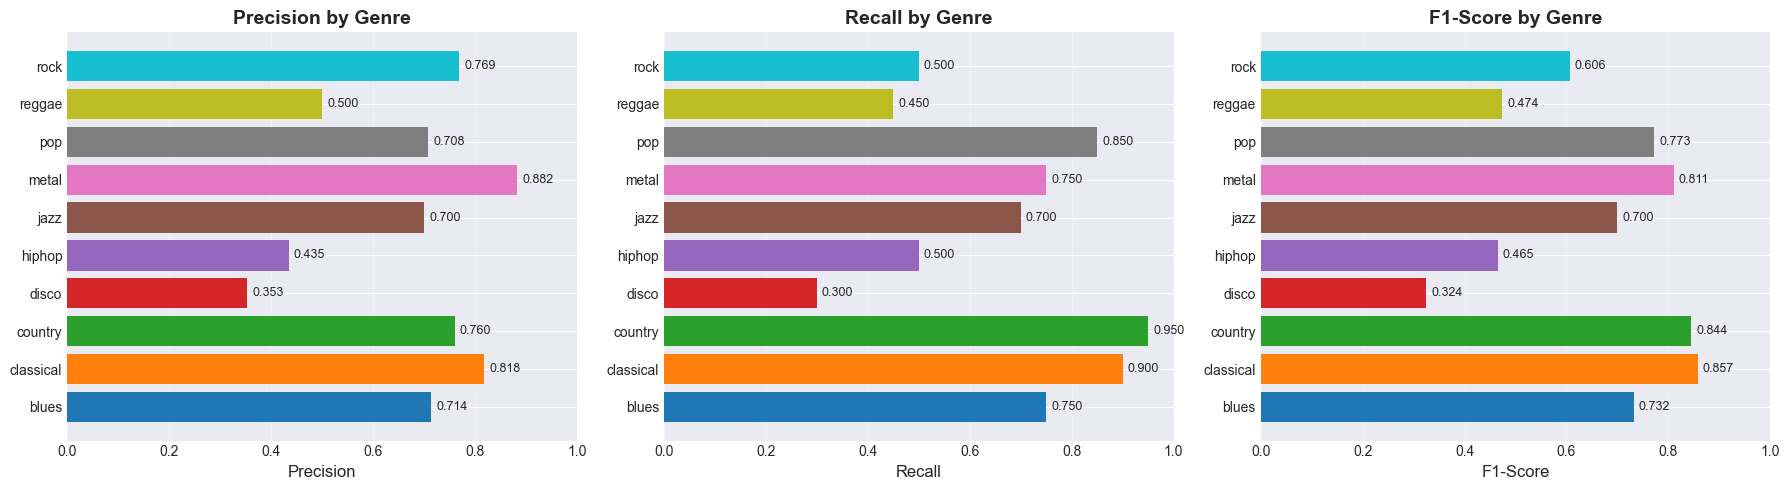

In [16]:
# 4.4 Per-Class Performance Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_data = {
    'Precision': test_metrics['precision_per_class'],
    'Recall': test_metrics['recall_per_class'],
    'F1-Score': test_metrics['f1_per_class']
}

for idx, (metric_name, values) in enumerate(metrics_data.items()):
    ax = axes[idx]
    bars = ax.barh(class_names, values, color=colors(range(len(class_names))))
    ax.set_xlabel(metric_name, fontsize=12)
    ax.set_title(f'{metric_name} by Genre', fontsize=14, fontweight='bold')
    ax.set_xlim([0, 1])
    ax.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, values)):
        ax.text(val + 0.01, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


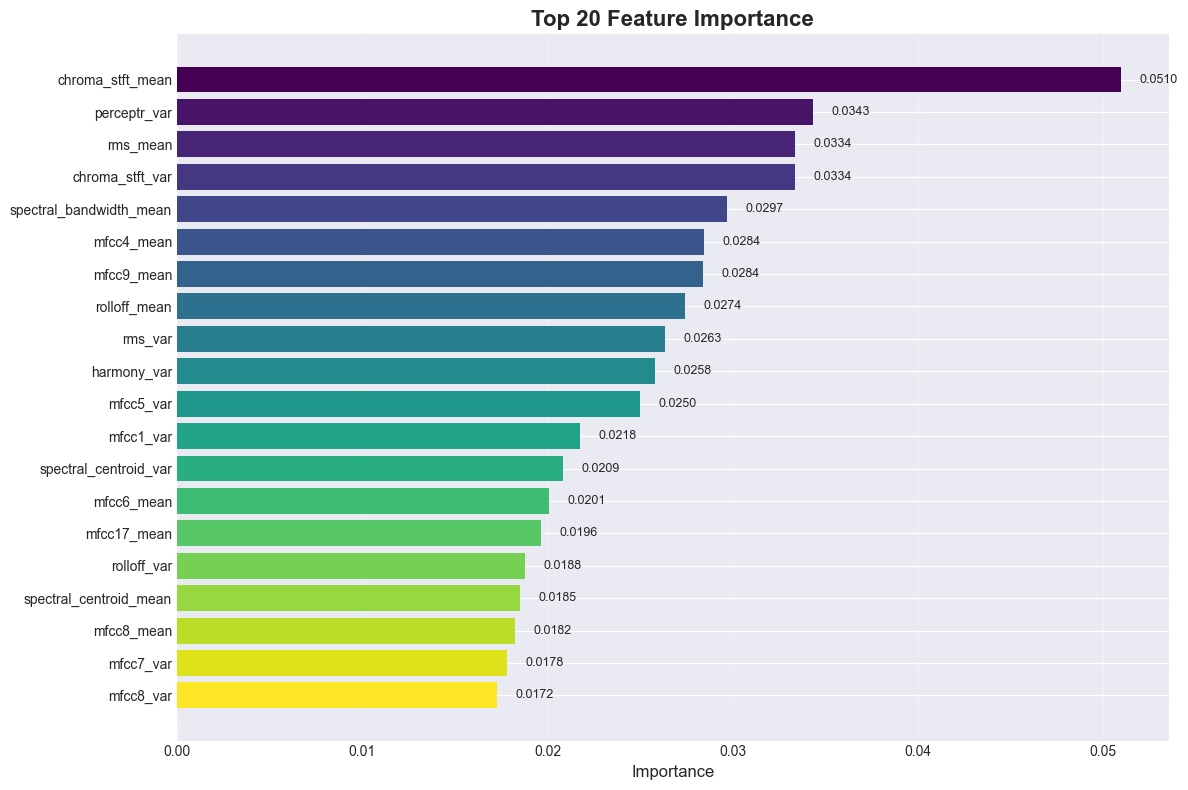

In [17]:
# 4.5 Feature Importance (if available)
feature_importance = classifier.get_feature_importance()

if feature_importance is not None:
    # Get top 20 features
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importance
    }).sort_values('importance', ascending=False).head(20)
    
    plt.figure(figsize=(12, 8))
    bars = plt.barh(range(len(importance_df)), importance_df['importance'], 
                    color=plt.cm.viridis(np.linspace(0, 1, len(importance_df))))
    plt.yticks(range(len(importance_df)), importance_df['feature'])
    plt.xlabel('Importance', fontsize=12)
    plt.title('Top 20 Feature Importance', fontsize=16, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, importance_df['importance'])):
        plt.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance not available for this model type.")


## 5. Model Interpretation


In [18]:
# 5.1 Error Analysis - Misclassified Samples
misclassified_mask = y_test != y_pred
misclassified_indices = np.where(misclassified_mask)[0]

print(f"Total misclassified samples: {len(misclassified_indices)} ({len(misclassified_indices)/len(y_test)*100:.2f}%)")
print(f"\nMisclassification breakdown:")

misclassification_counts = {}
for idx in misclassified_indices:
    actual = class_names[y_test[idx]]
    predicted = class_names[y_pred[idx]]
    key = f"{actual} -> {predicted}"
    misclassification_counts[key] = misclassification_counts.get(key, 0) + 1

# Sort by count
sorted_misclass = sorted(misclassification_counts.items(), key=lambda x: x[1], reverse=True)

print("\nMost common misclassifications:")
for pair, count in sorted_misclass[:10]:
    print(f"  {pair}: {count} samples")


Total misclassified samples: 67 (33.50%)

Misclassification breakdown:

Most common misclassifications:
  disco -> hiphop: 6 samples
  reggae -> hiphop: 5 samples
  hiphop -> reggae: 4 samples
  disco -> pop: 3 samples
  rock -> jazz: 3 samples
  hiphop -> pop: 3 samples
  jazz -> classical: 3 samples
  blues -> reggae: 3 samples
  metal -> disco: 2 samples
  rock -> country: 2 samples



Per-Genre Performance (sorted by F1-Score):
    Genre  Precision  Recall  F1-Score  ROC-AUC  Support
classical   0.818182    0.90  0.857143 0.994306       20
  country   0.760000    0.95  0.844444 0.985833       20
    metal   0.882353    0.75  0.810811 0.960833       20
      pop   0.708333    0.85  0.772727 0.973333       20
    blues   0.714286    0.75  0.731707 0.979306       20
     jazz   0.700000    0.70  0.700000 0.980972       20
     rock   0.769231    0.50  0.606061 0.844583       20
   reggae   0.500000    0.45  0.473684 0.855556       20
   hiphop   0.434783    0.50  0.465116 0.952639       20
    disco   0.352941    0.30  0.324324 0.865000       20


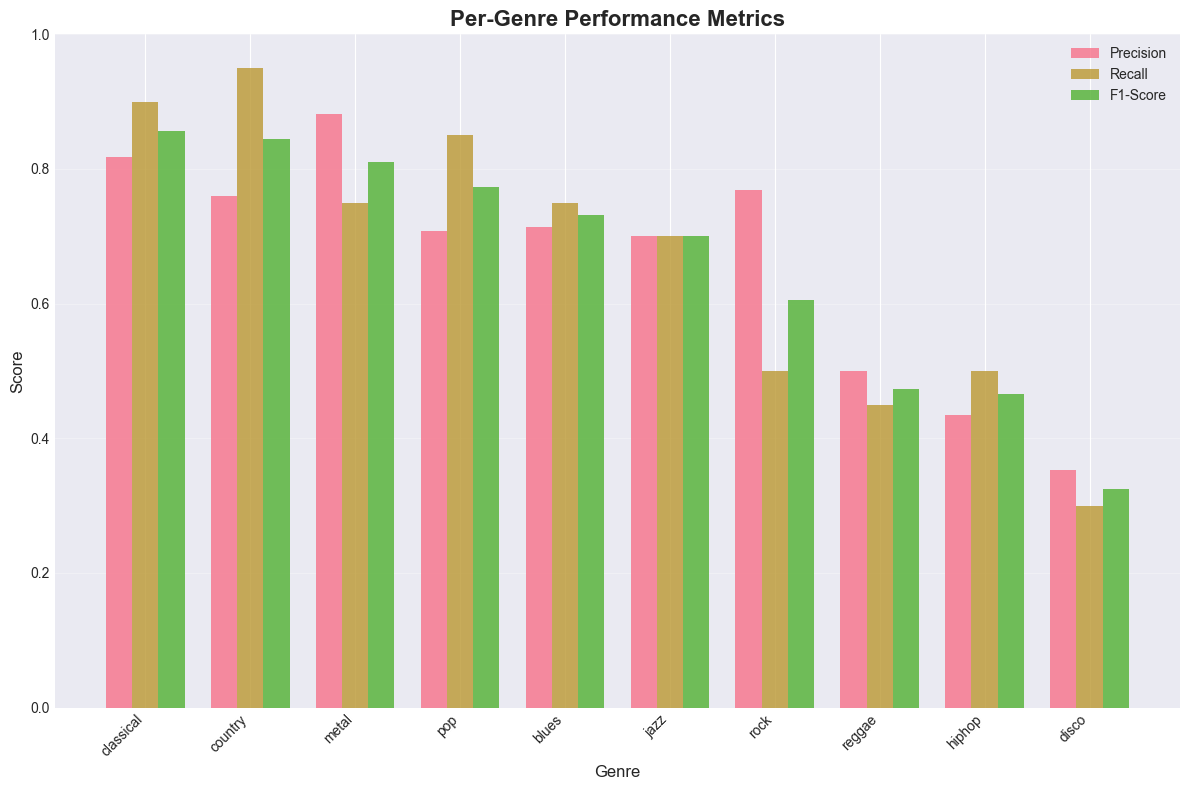

In [19]:
# 5.2 Per-Genre Performance Breakdown
performance_df = pd.DataFrame({
    'Genre': class_names,
    'Precision': test_metrics['precision_per_class'],
    'Recall': test_metrics['recall_per_class'],
    'F1-Score': test_metrics['f1_per_class'],
    'ROC-AUC': [roc_auc_scores[g] for g in class_names],
    'Support': [np.sum(y_test == i) for i in range(len(class_names))]
})

performance_df = performance_df.sort_values('F1-Score', ascending=False)

print("\nPer-Genre Performance (sorted by F1-Score):")
print(performance_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(12, 8))
x = np.arange(len(class_names))
width = 0.25

ax.bar(x - width, performance_df['Precision'], width, label='Precision', alpha=0.8)
ax.bar(x, performance_df['Recall'], width, label='Recall', alpha=0.8)
ax.bar(x + width, performance_df['F1-Score'], width, label='F1-Score', alpha=0.8)

ax.set_xlabel('Genre', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Per-Genre Performance Metrics', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(performance_df['Genre'], rotation=45, ha='right')
ax.legend()
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [20]:
# 5.3 Feature Importance Analysis (if available)
if feature_importance is not None:
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importance
    }).sort_values('importance', ascending=False)
    
    print("\nTop 10 Most Important Features:")
    print(importance_df.head(10).to_string(index=False))
    
    print("\nBottom 10 Least Important Features:")
    print(importance_df.tail(10).to_string(index=False))
    
    # Feature categories analysis
    feature_categories = {
        'Chroma': [f for f in feature_names if 'chroma' in f],
        'RMS': [f for f in feature_names if 'rms' in f],
        'Spectral': [f for f in feature_names if 'spectral' in f],
        'MFCC': [f for f in feature_names if 'mfcc' in f],
        'Tempo': [f for f in feature_names if 'tempo' in f],
        'Harmony': [f for f in feature_names if 'harmony' in f],
        'ZCR': [f for f in feature_names if 'zero_crossing' in f]
    }
    
    category_importance = {}
    for category, features in feature_categories.items():
        if features:
            category_importance[category] = importance_df[
                importance_df['feature'].isin(features)
            ]['importance'].mean()
    
    print("\nAverage Importance by Feature Category:")
    for category, avg_imp in sorted(category_importance.items(), key=lambda x: x[1], reverse=True):
        print(f"  {category:15s}: {avg_imp:.6f}")



Top 10 Most Important Features:
                feature  importance
       chroma_stft_mean    0.050999
           perceptr_var    0.034325
               rms_mean    0.033363
        chroma_stft_var    0.033359
spectral_bandwidth_mean    0.029671
             mfcc4_mean    0.028447
             mfcc9_mean    0.028399
           rolloff_mean    0.027446
                rms_var    0.026340
            harmony_var    0.025782

Bottom 10 Least Important Features:
    feature  importance
 mfcc18_var    0.011230
 mfcc15_var    0.011027
mfcc18_mean    0.010665
 mfcc12_var    0.010366
  mfcc2_var    0.010286
 mfcc14_var    0.010135
mfcc16_mean    0.009786
 mfcc17_var    0.008966
 mfcc16_var    0.008484
      tempo    0.007457

Average Importance by Feature Category:
  Chroma         : 0.042179
  RMS            : 0.029851
  Harmony        : 0.020955
  Spectral       : 0.020451
  MFCC           : 0.014983
  ZCR            : 0.014089
  Tempo          : 0.007457


## 6. Summary and Conclusions

### Key Findings:
Run the cells above to see:
1. **Best Model**: Determined from model comparison
2. **Test Accuracy**: Overall model performance
3. **Best Performing Genre**: Genre with highest F1-Score
4. **Worst Performing Genre**: Genre with lowest F1-Score

### Recommendations:
- Consider hyperparameter tuning for better performance
- Address class imbalance if present
- Feature engineering based on importance analysis
- Try ensemble methods for improved accuracy
- Collect more training data for poorly performing genres
